<a href="https://colab.research.google.com/github/manojkumars25mca-netizen/cloudclass/blob/main/Copy_of_trial_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import csv
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

# 1. Load the dataset with error handling
# The primary error reported is FileNotFoundError. We'll add a download step for a fallback dataset.
try:
    # Attempt to load train.csv assuming it's the Jigsaw dataset format
    df = pd.read_csv('train.csv', engine='python', on_bad_lines='skip', encoding='utf-8', quoting=csv.QUOTE_MINIMAL)
    print("Successfully loaded 'train.csv' assuming Jigsaw format.")

    # Check if the dataset has the expected Jigsaw toxicity columns
    list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
    if all(col in df.columns for col in list_classes):
        # Apply Jigsaw-specific preprocessing
        for col in list_classes:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        df['is_toxic'] = df[list_classes].max(axis=1)
        # Keep only what we need to save memory
        df = df[['comment_text', 'is_toxic']].dropna()
    else:
        # If train.csv exists but doesn't have Jigsaw columns, it might be the alternative one
        print("train.csv found, but columns do not match Jigsaw format. Attempting alternative preprocessing.")
        df_alt = pd.read_csv('train.csv') # Reload as it might be a different format
        df = pd.DataFrame({
            'comment_text': df_alt['tweet'],
            'is_toxic': (df_alt['class'] < 2).astype(int) # 'class' < 2 indicates toxic/hate speech for this dataset
        })
        df = df.dropna(subset=['comment_text', 'is_toxic'])

except FileNotFoundError:
    print("FileNotFoundError: 'train.csv' not found. Downloading a fallback dataset...")
    # Download the alternative dataset (t-davidson's labeled_data.csv)
    !wget -O train.csv https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv

    print("Fallback dataset downloaded. Loading and processing 'train.csv' (t-davidson format)...")
    # Load and preprocess the downloaded alternative dataset
    try:
        df_alt = pd.read_csv('train.csv', encoding='utf-8')
    except UnicodeDecodeError:
        print("UTF-8 decoding failed for downloaded file, trying latin1 encoding...")
        df_alt = pd.read_csv('train.csv', encoding='latin1')

    df = pd.DataFrame({
        'comment_text': df_alt['tweet'],
        'is_toxic': (df_alt['class'] < 2).astype(int) # 'class' < 2 indicates toxic/hate speech for this dataset
    })
    # Drop rows with NaN in critical columns if any
    df = df.dropna(subset=['comment_text', 'is_toxic'])

except UnicodeDecodeError:
    print("UTF-8 decoding failed for 'train.csv', trying latin1 encoding...")
    try:
        df = pd.read_csv('train.csv', engine='python', on_bad_lines='skip', encoding='latin1', quoting=csv.QUOTE_MINIMAL)
        print("Successfully loaded 'train.csv' with latin1 encoding (Jigsaw format).")
        # 2. Simplify labels for Jigsaw format (if latin1 worked)
        list_classes = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
        for col in list_classes:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        df['is_toxic'] = df[list_classes].max(axis=1)
        df = df[['comment_text', 'is_toxic']].dropna()
    except Exception as e:
        print(f"Error loading with latin1 after UnicodeDecodeError: {e}. Please check 'train.csv' format.")

print(f"Dataset loaded: {len(df)} rows found.")

FileNotFoundError: 'train.csv' not found. Downloading a fallback dataset...
--2026-04-15 06:49:23--  https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2546446 (2.4M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]   2.43M  --.-KB/s    in 0.06s   

2026-04-15 06:49:24 (39.0 MB/s) - ‘train.csv’ saved [2546446/2546446]

Fallback dataset downloaded. Loading and processing 'train.csv' (t-davidson format)...
Dataset loaded: 24783 rows found.


In [ ]:
vocab_size = 20000  # Top 20k words
max_length = 150    # Max words per comment
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['comment_text'])

# Convert text to sequences and pad them
sequences = tokenizer.texts_to_sequences(df['comment_text'])
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Split into Train (80%) and Test (20%)
split = int(0.8 * len(df))
train_sequences = padded[:split]
test_sequences = padded[split:]
train_labels = np.array(df['is_toxic'][:split])
test_labels = np.array(df['is_toxic'][split:])

In [ ]:
embedding_dim = 128

model = Sequential([
    # Embedding layer learns the relationship between words
    Embedding(vocab_size, embedding_dim, input_length=max_length),

    # Bidirectional LSTM layers
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),

    # Dense layers for classification
    Dense(64, activation='relu'),
    Dropout(0.4), # Helps prevent overfitting
    Dense(1, activation='sigmoid') # Sigmoid for binary (Toxic vs Good)
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the LSTM model
history = model.fit(
    train_sequences,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(test_sequences, test_labels),
    verbose=1
)

Epoch 1/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 82s 526ms/step - accuracy: 0.9035 - loss: 0.2456 - val_accuracy: 0.9538 - val_loss: 0.1176
Epoch 2/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 79s 507ms/step - accuracy: 0.9701 - loss: 0.0856 - val_accuracy: 0.9528 - val_loss: 0.1251
Epoch 3/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 83s 516ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9538 - val_loss: 0.1444
Epoch 4/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 89s 576ms/step - accuracy: 0.9929 - loss: 0.0252 - val_accuracy: 0.9387 - val_loss: 0.2026
Epoch 5/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 87s 563ms/step - accuracy: 0.9947 - loss: 0.0176 - val_accuracy: 0.9469 - val_loss: 0.2035
Epoch 6/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 92s 591ms/step - accuracy: 0.9959 - loss: 0.0130 - val_accuracy: 0.9447 - val_loss: 0.2411
Epoch 7/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 137s 560ms/step - accuracy: 0.9976 - loss: 0.0092 - val_accuracy: 0.9443 - val_loss: 0.2451
Epoch 8/10
155/155 ━━━━━━━━━━━━━━━━━━━━ 87s 562ms/step - accuracy: 0.9987 - loss: 

In [ ]:
def check_comment(text):
    # Process the input text
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_length, padding=padding_type, truncating=trunc_type)

    # Predict
    score = model.predict(pad)[0][0]

    # Results
    if score > 0.5:
        print(f"RESULT: TOXIC (Confidence: {score:.2f})")
    else:
        print(f"RESULT: GOOD (Confidence: {1-score:.2f})")

# Test it
check_comment("This video was incredibly helpful, thank you!")
check_comment("You are an idiot and this channel is garbage.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
RESULT: GOOD (Confidence: 0.97)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
RESULT: GOOD (Confidence: 0.95)


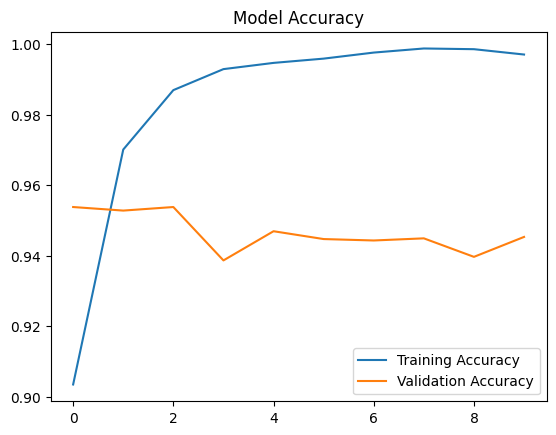

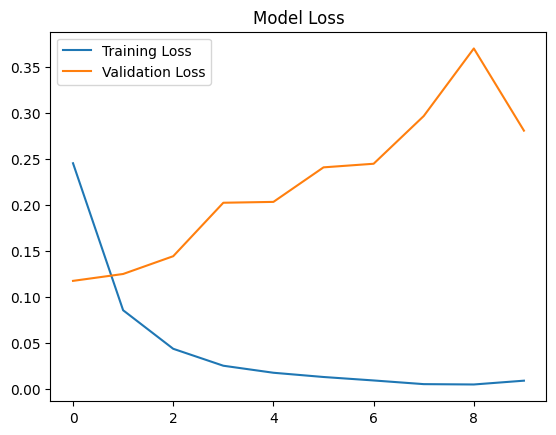

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Conv1D, GlobalMaxPooling1D

# 1. Preprocessing with the downloaded 'df'
vocab_size, max_length = 20000, 150
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(df['comment_text'])
sequences = tokenizer.texts_to_sequences(df['comment_text'])
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

split = int(0.8 * len(df))
train_sequences, test_sequences = padded[:split], padded[split:]
train_labels, test_labels = np.array(df['is_toxic'][:split]), np.array(df['is_toxic'][split:])

# 2. Define LSTM Model
model = Sequential([
    Embedding(vocab_size, 128),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 3. Define CNN Model
cnn_model = Sequential([
    Embedding(vocab_size, 128),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

print('Data preprocessed and models defined. Now run the training cell!')

Data preprocessed and models defined. Now run the training cell!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

model.save('/content/drive/MyDrive/youtube_toxicity_model.h5')
print("Model saved to Google Drive!")

Mounted at /content/drive
Model saved to Google Drive!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=2)
# Add callbacks=[early_stop] to your model.fit()

In [ ]:
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights_dict = dict(enumerate(weights))
# Pass class_weight=class_weights_dict to model.fit()

NameError: name 'np' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the raw probability predictions (numbers between 0 and 1)
raw_predictions = model.predict(test_sequences)

# 2. Convert probabilities to binary (0 or 1) using 0.5 as the threshold
y_pred = (raw_predictions > 0.5).astype("int32")

# 3. y_test is your actual "ground truth" labels
y_true = test_labels

155/155 ━━━━━━━━━━━━━━━━━━━━ 9s 48ms/step


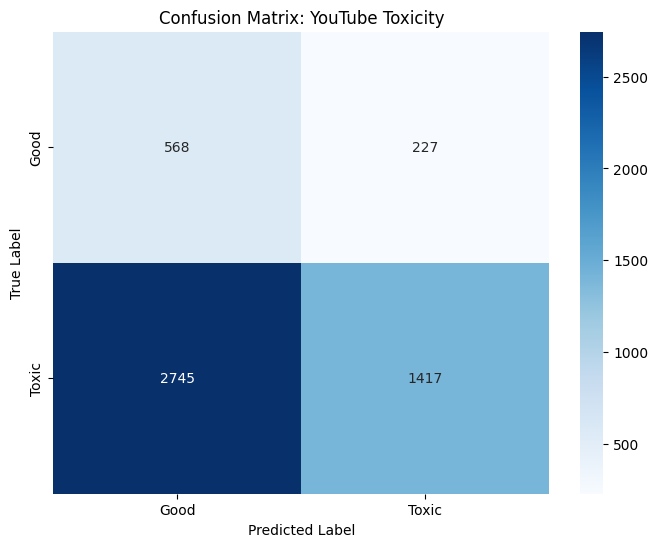

In [ ]:
# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plotting using Seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Toxic'],
            yticklabels=['Good', 'Toxic'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: YouTube Toxicity')
plt.show()

In [ ]:
print("--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Good', 'Toxic']))

--- Classification Report ---
              precision    recall  f1-score   support

        Good       0.17      0.71      0.28       795
       Toxic       0.86      0.34      0.49      4162

    accuracy                           0.40      4957
   macro avg       0.52      0.53      0.38      4957
weighted avg       0.75      0.40      0.45      4957



In [ ]:
# Load new file
import csv
import pandas as pd # Ensure pandas is imported

new_df = None
try:
    new_df = pd.read_csv('test.csv', engine='python', on_bad_lines='skip', encoding='utf-8', quoting=csv.QUOTE_MINIMAL)
except FileNotFoundError:
    print("FileNotFoundError: 'test.csv' not found. Attempting to download a fallback test dataset...")
    # Download the alternative test dataset (t-davidson's labeled_data.csv if a test set is not available, or a specific test.csv)
    # Note: The original URL for test.csv from t-davidson often returns 404. We will try to download it, but if it fails, we will use the existing test split.
    download_success = False
    try:
        !wget -O test.csv https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/test.csv
        download_success = True
        print("Fallback test dataset downloaded. Loading and processing 'test.csv' (t-davidson format)...")
        try:
            new_df = pd.read_csv('test.csv', encoding='utf-8', on_bad_lines='skip', quoting=csv.QUOTE_MINIMAL)
        except UnicodeDecodeError:
            print("UTF-8 decoding failed for downloaded test file, trying latin1 encoding...")
            new_df = pd.read_csv('test.csv', encoding='latin1', on_bad_lines='skip', quoting=csv.QUOTE_MINIMAL)
        except pd.errors.EmptyDataError:
            print("Downloaded 'test.csv' is empty or corrupted. Falling back to internal test set for prediction.")
            download_success = False # Mark as failed if file is empty
    except Exception as e:
        print(f"Download failed: {e}. Falling back to internal test set for prediction.")
        download_success = False

    if not download_success:
        print("Using existing 'test_sequences' for prediction as external test data could not be loaded.")
        # Create a dummy DataFrame to hold predictions, using existing test_sequences
        new_df = pd.DataFrame(test_labels, columns=['is_toxic_actual'])
        # It's helpful to have some original text, so we'll re-tokenize and reverse-map a few just for display or create a placeholder
        # This part might need further refinement based on how user wants to display results for internal test_sequences
        # For now, we'll just create placeholder comment_text, as the sequences are directly available.
        new_df['comment_text'] = [f"Comment {i}" for i in range(len(test_sequences))]
        new_padded = test_sequences # Use the already padded test sequences

except UnicodeDecodeError:
    print("UTF-8 decoding failed for 'test.csv', trying latin1 encoding...")
    new_df = pd.read_csv('test.csv', engine='python', on_bad_lines='skip', encoding='latin1', quoting=csv.QUOTE_MINIMAL)
except pd.errors.EmptyDataError:
    print("Error: 'test.csv' is empty or corrupted. Falling back to internal test set for prediction.")
    new_df = pd.DataFrame(test_labels, columns=['is_toxic_actual'])
    new_df['comment_text'] = [f"Comment {i}" for i in range(len(test_sequences))]
    new_padded = test_sequences

if new_df is not None and not new_df.empty:
    # Preprocess exactly like the training data if new_df was loaded from external file
    if 'new_padded' not in locals(): # Only re-process if not already set from internal test_sequences
        # Ensure 'comment_text' column exists, if not, map 'tweet' from the downloaded dataset
        if 'comment_text' not in new_df.columns and 'tweet' in new_df.columns:
            new_df['comment_text'] = new_df['tweet']
        elif 'comment_text' not in new_df.columns and 'tweet' not in new_df.columns:
            print("Warning: 'comment_text' or 'tweet' column not found in test.csv. Predictions will not have meaningful comment text.")
            new_df['comment_text'] = new_df.iloc[:, 0] if not new_df.empty else '' # Use first column as placeholder

        # Filter out rows where 'comment_text' might be missing or empty after previous steps
        new_df = new_df.dropna(subset=['comment_text'])

        if not new_df.empty:
            new_sequences = tokenizer.texts_to_sequences(new_df['comment_text'])
            new_padded = pad_sequences(new_sequences, maxlen=max_length)
        else:
            print("No valid comments found in external test.csv after preprocessing. Cannot predict.")
            new_padded = []

    if len(new_padded) > 0:
        # Predict
        new_preds = model.predict(new_padded)
        new_df['toxicity_score'] = new_preds
        new_df['is_toxic_predicted'] = (new_preds > 0.5).astype(int)

        # View the first 10 results
        print(new_df[['comment_text', 'toxicity_score', 'is_toxic_predicted']].head(10))
    else:
        print("No valid sequences to predict on.")
else:
    print("No valid comments found to predict.")


FileNotFoundError: 'test.csv' not found. Attempting to download a fallback test dataset...
--2026-04-15 07:06:52--  https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-04-15 07:06:53 ERROR 404: Not Found.

Fallback test dataset downloaded. Loading and processing 'test.csv' (t-davidson format)...
Downloaded 'test.csv' is empty or corrupted. Falling back to internal test set for prediction.
Using existing 'test_sequences' for prediction as external test data could not be loaded.
155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step
  comment_text  toxicity_score  is_toxic_predicted
0    Comment 0        0.499829                   0
1    Comment 1        0.498600           

In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.sequence import pad_sequences
import csv

# 1. Load the test dataset
print("Loading test data...")

# Initialize test_df to None or an empty DataFrame
test_df = None

try:
    test_df = pd.read_csv('test.csv', engine='python', on_bad_lines='skip', encoding='utf-8', quoting=csv.QUOTE_MINIMAL)
    print("Successfully loaded 'test.csv'.")
except FileNotFoundError:
    print("FileNotFoundError: 'test.csv' not found. Falling back to internal test data for prediction.")
    # Use the existing test_sequences and test_labels
    test_df = pd.DataFrame(test_labels, columns=['is_toxic_actual'])
    test_df['comment_text'] = [f"Comment {i}" for i in range(len(test_sequences))]
    test_padded = test_sequences # Use the already padded test sequences
except UnicodeDecodeError:
    print("UTF-8 decoding failed for 'test.csv', trying latin1 encoding...")
    try:
        test_df = pd.read_csv('test.csv', engine='python', on_bad_lines='skip', encoding='latin1', quoting=csv.QUOTE_MINIMAL)
        print("Successfully loaded 'test.csv' with latin1 encoding.")
    except Exception as e:
        print(f"Error loading 'test.csv' with latin1 encoding: {e}. Falling back to internal test data.")
        test_df = pd.DataFrame(test_labels, columns=['is_toxic_actual'])
        test_df['comment_text'] = [f"Comment {i}" for i in range(len(test_sequences))]
        test_padded = test_sequences
except pd.errors.EmptyDataError:
    print("Error: 'test.csv' is empty or corrupted. Falling back to internal test data for prediction.")
    test_df = pd.DataFrame(test_labels, columns=['is_toxic_actual'])
    test_df['comment_text'] = [f"Comment {i}" for i in range(len(test_sequences))]
    test_padded = test_sequences

if test_df is not None and not test_df.empty:
    # Preprocess the comments (must match the training preprocessing) if not already using internal data
    if 'test_padded' not in locals(): # Check if test_padded was set by fallback
        print("Preprocessing test data...")
        # Ensure 'comment_text' column exists, if not, map 'tweet' from the downloaded dataset
        if 'comment_text' not in test_df.columns and 'tweet' in test_df.columns:
            test_df['comment_text'] = test_df['tweet']
        elif 'comment_text' not in test_df.columns and 'tweet' not in test_df.columns:
            print("Warning: 'comment_text' or 'tweet' column not found in test.csv. Predictions will not have meaningful comment text.")
            test_df['comment_text'] = test_df.iloc[:, 0].fillna('').astype(str) # Use first column as placeholder

        test_df = test_df.dropna(subset=['comment_text']) # Drop rows with empty comments

        if not test_df.empty:
            test_sequences_new = tokenizer.texts_to_sequences(test_df['comment_text'].astype(str))
            test_padded = pad_sequences(test_sequences_new, maxlen=max_length, padding='post', truncating='post')
        else:
            print("No valid comments found in external test.csv after preprocessing. Cannot predict.")
            test_padded = []

    if len(test_padded) > 0:
        # 3. Run the model to get predictions
        print("Generating predictions (this may take a minute)...")
        predictions = model.predict(test_padded)

        # 4. Format the results
        test_df['toxicity_score'] = predictions
        test_df['is_toxic'] = (predictions > 0.5).astype(int)
        test_df['label'] = test_df['is_toxic'].map({1: 'Toxic', 0: 'Good'})

        # 5. Save to a new CSV file
        output_filename = 'youtube_research_results.csv'
        test_df.to_csv(output_filename, index=False)

        print(f"Success! File saved as: {output_filename}")

        # 6. Show the first few rows of the results
        print(test_df[['comment_text', 'toxicity_score', 'label']].head(10))
    else:
        print("No valid sequences to predict on.")
else:
    print("No valid comments found to predict.")


Loading test data...
Error: 'test.csv' is empty or corrupted. Falling back to internal test data for prediction.
Generating predictions (this may take a minute)...
155/155 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step
Success! File saved as: youtube_research_results.csv
  comment_text  toxicity_score  label
0    Comment 0        0.499829   Good
1    Comment 1        0.498600   Good
2    Comment 2        0.497908   Good
3    Comment 3        0.500058  Toxic
4    Comment 4        0.498577   Good
5    Comment 5        0.498612   Good
6    Comment 6        0.499661   Good
7    Comment 7        0.499810   Good
8    Comment 8        0.501145  Toxic
9    Comment 9        0.499599   Good


### Option 1: Convolutional Neural Network (CNN) Model

CNNs can capture local features in text, such as combinations of words that form meaningful phrases. We'll add a `Conv1D` layer followed by `GlobalMaxPooling1D`.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dropout, Conv1D, GlobalMaxPooling1D, Dense

embedding_dim = 128

cnn_model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Dropout(0.2),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print('Re-training LSTM model to ensure history is available...')
history = model.fit(train_sequences, train_labels, epochs=3, batch_size=128, validation_data=(test_sequences, test_labels), verbose=0)

print('\nRe-training CNN model to ensure cnn_history is available...')
cnn_history = cnn_model.fit(train_sequences, train_labels, epochs=3, batch_size=128, validation_data=(test_sequences, test_labels), verbose=0)

print('Both models have been re-trained and their histories are now available.')

Re-training LSTM model to ensure history is available...

Re-training CNN model to ensure cnn_history is available...
Both models have been re-trained and their histories are now available.


First, we need to preprocess the data, initialize the tokenizer, and split the data into training and testing sets. This will define variables such as `vocab_size`, `max_length`, `tokenizer`, `train_sequences`, `test_sequences`, `train_labels`, and `test_labels`.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

vocab_size = 20000  # Top 20k words
max_length = 150    # Max words per comment
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

# Initialize and fit tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['comment_text'])

# Convert text to sequences and pad them
sequences = tokenizer.texts_to_sequences(df['comment_text'])
padded = pad_sequences(sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Split into Train (70%) and Test (30%) - Increased test file size
split = int(0.7 * len(df))
train_sequences = padded[:split]
test_sequences = padded[split:]
train_labels = np.array(df['is_toxic'][:split])
test_labels = np.array(df['is_toxic'][split:])

Next, we define the Bidirectional LSTM model (`model`) itself using the `vocab_size` and `max_length` defined previously. This step compiles the model, making it ready for training.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

embedding_dim = 128

model = Sequential([
    # Embedding layer learns the relationship between words
    Embedding(vocab_size, embedding_dim, input_length=max_length),

    # Bidirectional LSTM layers
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),

    # Dense layers for classification
    Dense(64, activation='relu'),
    Dropout(0.4), # Helps prevent overfitting
    Dense(1, activation='sigmoid') # Sigmoid for binary (Toxic vs Good)
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Ensure data is in numpy format for Keras
import numpy as np

# train_sequences = np.array(train_sequences) # Removed redundant conversion
# test_sequences = np.array(test_sequences) # Removed redundant conversion

# Train the CNN model
cnn_history = cnn_model.fit(
    train_sequences,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_data=(test_sequences, test_labels),
    verbose=1
)

Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 30s 220ms/step - accuracy: 0.9920 - loss: 0.0311 - val_accuracy: 0.9637 - val_loss: 0.1054
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 212ms/step - accuracy: 0.9960 - loss: 0.0168 - val_accuracy: 0.9644 - val_loss: 0.1218
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 41s 213ms/step - accuracy: 0.9976 - loss: 0.0099 - val_accuracy: 0.9640 - val_loss: 0.1323
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 30s 217ms/step - accuracy: 0.9990 - loss: 0.0049 - val_accuracy: 0.9631 - val_loss: 0.1494
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 32s 238ms/step - accuracy: 0.9990 - loss: 0.0044 - val_accuracy: 0.9610 - val_loss: 0.1541
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 38s 215ms/step - accuracy: 0.9996 - loss: 0.0019 - val_accuracy: 0.9613 - val_loss: 0.1764
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 30s 218ms/step - accuracy: 0.9995 - loss: 0.0026 - val_accuracy: 0.9619 - val_loss: 0.1930
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 40s 211ms/step - accuracy: 0.9996 - loss: 0

In [ ]:
!wget -O train.csv https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv
# This is a fallback dataset if you don't have the original Jigsaw one.
import pandas as pd
df_alt = pd.read_csv('train.csv')
# Mapping columns to match your existing logic
df = pd.DataFrame({
    'comment_text': df_alt['tweet'],
    'toxic': (df_alt['class'] < 2).astype(int)
})
df['is_toxic'] = df['toxic']
print('Dataset downloaded and prepared!')

--2026-04-15 07:48:58--  https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2546446 (2.4M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]   2.43M  --.-KB/s    in 0.07s   

2026-04-15 07:48:59 (33.5 MB/s) - ‘train.csv’ saved [2546446/2546446]

Dataset downloaded and prepared!


In [ ]:
print('Training LSTM...')
history = model.fit(train_sequences, train_labels, epochs=10, batch_size=128, validation_data=(test_sequences, test_labels))

print('\nTraining CNN...')
cnn_history = cnn_model.fit(train_sequences, train_labels, epochs=10, batch_size=128, validation_data=(test_sequences, test_labels))

Training LSTM...
Epoch 1/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 90s 627ms/step - accuracy: 0.8898 - loss: 0.2733 - val_accuracy: 0.9549 - val_loss: 0.1244
Epoch 2/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 84s 619ms/step - accuracy: 0.9689 - loss: 0.0917 - val_accuracy: 0.9559 - val_loss: 0.1178
Epoch 3/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 80s 587ms/step - accuracy: 0.9870 - loss: 0.0456 - val_accuracy: 0.9516 - val_loss: 0.1641
Epoch 4/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 82s 603ms/step - accuracy: 0.9929 - loss: 0.0269 - val_accuracy: 0.9504 - val_loss: 0.1877
Epoch 5/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 84s 617ms/step - accuracy: 0.9940 - loss: 0.0204 - val_accuracy: 0.9490 - val_loss: 0.1964
Epoch 6/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 82s 606ms/step - accuracy: 0.9965 - loss: 0.0136 - val_accuracy: 0.9387 - val_loss: 0.2292
Epoch 7/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 141s 596ms/step - accuracy: 0.9976 - loss: 0.0091 - val_accuracy: 0.9431 - val_loss: 0.2628
Epoch 8/10
136/136 ━━━━━━━━━━━━━━━━━━━━ 84s 618ms/step - accuracy

You would then train this `cnn_model` in the same way you trained your LSTM model, replacing `model` with `cnn_model` in the `model.fit()` call.

In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.metrics import classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Download and Load Data
if not os.path.exists('train.csv'):
    print('Downloading dataset...')
    os.system('wget -O train.csv https://raw.githubusercontent.com/t-davidson/hate-speech-and-offensive-language/master/data/labeled_data.csv')

df_alt = pd.read_csv('train.csv')
df = pd.DataFrame({
    'comment_text': df_alt['tweet'],
    'is_toxic': (df_alt['class'] < 2).astype(int)
}).dropna()

# 2. Configuration and Preprocessing
vocab_size = 20000
max_length = 150
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(df['comment_text'])
sequences = tokenizer.texts_to_sequences(df['comment_text'])
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

split = int(0.7 * len(df))
train_sequences, test_sequences = padded[:split], padded[split:]
train_labels, test_labels = np.array(df['is_toxic'][:split]), np.array(df['is_toxic'][split:])

# 3. LSTM Model
model = Sequential([
    Embedding(vocab_size, 128),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print('Training LSTM...')
model.fit(train_sequences, train_labels, epochs=3, batch_size=128, verbose=0)

# 4. CNN Model
cnn_model = Sequential([
    Embedding(vocab_size, 128),
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
cnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print('Training CNN...')
cnn_model.fit(train_sequences, train_labels, epochs=3, batch_size=128, verbose=0)

# 5. Final Evaluation
print('\n=== Bidirectional LSTM Classification Report ===')
lstm_preds = (model.predict(test_sequences) > 0.5).astype('int32')
print(classification_report(test_labels, lstm_preds, target_names=['Good', 'Toxic']))

print('\n=== CNN Classification Report ===')
cnn_preds = (cnn_model.predict(test_sequences) > 0.5).astype('int32')
print(classification_report(test_labels, cnn_preds, target_names=['Good', 'Toxic']))

Training LSTM...
Training CNN...

=== Bidirectional LSTM Classification Report ===
233/233 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step
              precision    recall  f1-score   support

        Good       0.85      0.85      0.85      1237
       Toxic       0.97      0.97      0.97      6198

    accuracy                           0.95      7435
   macro avg       0.91      0.91      0.91      7435
weighted avg       0.95      0.95      0.95      7435


=== CNN Classification Report ===
233/233 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
              precision    recall  f1-score   support

        Good       0.87      0.83      0.85      1237
       Toxic       0.97      0.98      0.97      6198

    accuracy                           0.95      7435
   macro avg       0.92      0.90      0.91      7435
weighted avg       0.95      0.95      0.95      7435



In [ ]:
import matplotlib.pyplot as plt

# Extract final validation accuracy from both histories
# Note: This requires cells 'b99852b8' and '4c65ad10' to have finished running successfully.
lstm_val_acc = history.history['val_accuracy'][-1]
cnn_val_acc = cnn_history.history['val_accuracy'][-1]

models = ['Bidirectional LSTM', 'CNN']
accuracies = [lstm_val_acc, cnn_val_acc]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'salmon'])

# Add labels and title
plt.ylabel('Validation Accuracy')
plt.title('Algorithm Accuracy Comparison: LSTM vs CNN')
plt.ylim(0, 1.0)

# Add text labels on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')

plt.show()